# RQ1 / HR1 — operator clustering (A3), tightened

A1 = each label its own actor; A2 = collapse the tail; **A3** = merge labels that are
the **same operator**, evidenced by **shared payout addresses**. A first pass over-merged
(a single shared address chained independent majors into one blob). The fix: require
pools to share **at least `MIN_SHARED_ADDR` distinct addresses** before drawing an
edge, so incidental single-address co-payments don't link them. A **sweep** below shows
where the blob breaks, setting `MIN_SHARED_ADDR` to the smallest value where the major
pools separate.

Grouping by connected components (sanity) and Louvain (main); A3 folded into the RQ1
band alongside A2. Guards: skip many-output blocks (direct-payout pools), drop
addresses shared by too many pools (services). networkx is pure Python.

In [1]:
%matplotlib inline
import os, re, json
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import networkx as nx
    from networkx.algorithms.community import louvain_communities
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "networkx", "--quiet"])
    import networkx as nx
    from networkx.algorithms.community import louvain_communities

MAX_OUTPUTS = 10          # skip blocks with more coinbase outputs (direct-payout pools)
MAX_POOLS_PER_ADDR = 3    # drop addresses shared by more than this many pools (services)
MIN_SHARED_ADDR = 2       # require this many distinct shared addresses per edge (set from the sweep)
THRESHOLDS = [0.001, 0.005, 0.01, 0.02]

blk = pd.read_parquet("../data/raw/raw_blocks_full.parquet")
btc = json.load(open("../data/raw/pools.json", encoding="utf-8"))
btc_tag = {t: v["name"] for t, v in btc["coinbase_tags"].items()}
print(f"{len(blk):,} blocks | {len(btc_tag)} tags | MIN_SHARED_ADDR = {MIN_SHARED_ADDR}")

954,375 blocks | 149 tags | MIN_SHARED_ADDR = 2


## Attribute blocks by tag, keep payout addresses

In [2]:
def decode_coinbase(h):
    if not h: return ""
    try: return bytes.fromhex(h).decode("utf-8", errors="ignore")
    except (ValueError, TypeError): return str(h)

_pat = re.compile("|".join(re.escape(t) for t in sorted(btc_tag, key=len, reverse=True)))
def tag_match(text):
    m = _pat.search(text); return btc_tag[m.group(0)] if m else None

text = blk["coinbase_param"].astype("string").fillna("").map(decode_coinbase)
blk["pool"] = [tag_match(t) for t in text]
blk["month"] = pd.to_datetime(blk["timestamp"]).dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
known = blk[blk["pool"].notna()].copy()
print(f"tag-attributed blocks: {len(known):,} ({len(known)/len(blk):.1%})")

tag-attributed blocks: 668,409 (70.0%)


## Shared-address edges + the threshold sweep

`edge_w[(A,B)]` = number of distinct addresses A and B share. The sweep shows, per
`MIN_SHARED_ADDR`, how big the largest component gets, pick the smallest threshold
where the majors stop being fused into one giant operator.

In [3]:
addr2pools = defaultdict(set)
skipped = 0
for pool, addrs in zip(known["pool"], known["output_addresses"]):
    if addrs is None: continue
    if len(addrs) > MAX_OUTPUTS:
        skipped += 1; continue
    for a in addrs:
        addr2pools[a].add(pool)

edge_w = defaultdict(int); dropped_addr = 0
for a, pools in addr2pools.items():
    if len(pools) < 2: continue
    if len(pools) > MAX_POOLS_PER_ADDR:
        dropped_addr += 1; continue
    pl = sorted(pools)
    for i in range(len(pl)):
        for j in range(i + 1, len(pl)):
            edge_w[(pl[i], pl[j])] += 1

print(f"skipped {skipped:,} many-output blocks; dropped {dropped_addr} promiscuous addresses")
print("edge-weight distribution (shared-address count -> #edges):",
      dict(sorted(Counter(edge_w.values()).items())))

def build_graph(min_shared):
    G = nx.Graph(); G.add_nodes_from(known["pool"].unique())
    for (u, v), w in edge_w.items():
        if w >= min_shared:
            G.add_edge(u, v, weight=w)
    return G

print("\nsweep -- largest operator size as the edge threshold tightens:")
print(f"{'MIN_SHARED_ADDR':>16} {'edges':>7} {'largest (components)':>21} {'largest (louvain)':>18}")
for K in [1, 2, 3, 5]:
    Gk = build_graph(K)
    comp_big = max((len(c) for c in nx.connected_components(Gk)), default=1)
    lv = louvain_communities(Gk, weight="weight", seed=1) if Gk.number_of_edges() else [{n} for n in Gk]
    lv_big = max((len(c) for c in lv), default=1)
    print(f"{K:>16} {Gk.number_of_edges():>7} {comp_big:>21} {lv_big:>18}")

skipped 11,208 many-output blocks; dropped 42 promiscuous addresses
edge-weight distribution (shared-address count -> #edges): {1: 23, 2: 9, 3: 4, 4: 3, 5: 2, 6: 3, 7: 2, 9: 1, 10: 1, 12: 1, 13: 1, 19: 1, 23: 1, 25: 1, 31: 1, 46: 1, 55: 1, 58: 2, 69: 1, 71: 1, 164: 1, 193: 1, 229: 1, 232: 1, 267: 1, 343: 1, 1145: 1, 1354: 1, 1556: 1}

sweep -- largest operator size as the edge threshold tightens:
 MIN_SHARED_ADDR   edges  largest (components)  largest (louvain)
               1      69                    28                 12
               2      46                    19                  9
               3      37                    17                 10
               5      30                    12                  8


## Cluster at the chosen threshold-components (sanity) and Louvain (main)

In [4]:
G = build_graph(MIN_SHARED_ADDR)
print(f"graph @ MIN_SHARED_ADDR={MIN_SHARED_ADDR}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
comps = list(nx.connected_components(G))
louv = louvain_communities(G, weight="weight", seed=1) if G.number_of_edges() else [{n} for n in G]

def report(groups, name):
    multi = sorted([sorted(g) for g in groups if len(g) > 1], key=len, reverse=True)
    sizes = sorted((len(g) for g in groups), reverse=True)
    print(f"\n{name}: {len(groups)} operators; largest sizes {sizes[:5]}; {len(multi)} multi-label")
    for g in multi[:20]:
        share = known["pool"].isin(g).mean() * 100
        print(f"    {{{', '.join(g)}}}  ({share:.1f}% of blocks)")
    return multi

_ = report(comps, "components (sanity)")
_ = report(louv, "louvain (main)")

graph @ MIN_SHARED_ADDR=2: 108 nodes, 46 edges

components (sanity): 86 operators; largest sizes [19, 3, 2, 2, 1]; 4 multi-label
    {1THash, AntPool, ArkPool, BTC.TOP, Binance Pool, Braiins Pool, CloverPool, EMCDPool, EclipseMC, F2Pool, Huobi.pool, KuCoinPool, Luxor, OKKONG, Poolin, Sigmapool.com, ViaBTC, WAYI.CN, WhitePool}  (64.1% of blocks)
    {GBMiners, Helix, haominer}  (0.3% of blocks)
    {Bitparking, mmpool}  (0.1% of blocks)
    {NiceHash, Solo CK}  (0.0% of blocks)

louvain (main): 88 operators; largest sizes [9, 7, 3, 3, 2]; 6 multi-label
    {AntPool, Binance Pool, EclipseMC, F2Pool, KuCoinPool, Luxor, Poolin, ViaBTC, WhitePool}  (47.2% of blocks)


    {ArkPool, Braiins Pool, CloverPool, EMCDPool, Huobi.pool, OKKONG, Sigmapool.com}  (13.4% of blocks)
    {GBMiners, Helix, haominer}  (0.3% of blocks)
    {1THash, BTC.TOP, WAYI.CN}  (3.5% of blocks)
    {Bitparking, mmpool}  (0.1% of blocks)
    {NiceHash, Solo CK}  (0.0% of blocks)


## Relabel by operator (dominant label names each operator)

In [5]:
pool_blocks = known["pool"].value_counts()
def operator_map(groups):
    m = {}
    for g in groups:
        dom = max(g, key=lambda p: pool_blocks.get(p, 0))
        for p in g: m[p] = dom
    return m
op_comp = operator_map(comps)
op_louv = operator_map(louv)
print(f"labels absorbed -- components: {sum(p!=o for p,o in op_comp.items())}, "
      f"louvain: {sum(p!=o for p,o in op_louv.items())}")

labels absorbed -- components: 22, louvain: 20


## Metrics under every actor definition (A1, A2 sweep, A3)

In [6]:
def _sh(c): c = np.asarray(c, float); s = c.sum(); return c / s if s > 0 else c
def nakamoto(c): p = np.sort(_sh(c))[::-1]; return int((np.cumsum(p) <= 0.5).sum() + 1) if len(p) else 0
def hhi(c): p = _sh(c); return float((p ** 2).sum())
def gini(c):
    p = np.sort(_sh(c)); n = len(p)
    if n == 0 or p.sum() == 0: return 0.0
    idx = np.arange(1, n + 1); return float((2 * (idx * p).sum()) / (n * p.sum()) - (n + 1) / n)
def shannon(c): p = _sh(c); p = p[p > 0]; return float(-(p * np.log2(p)).sum()) if len(p) else 0.0
def cr(c, k): p = np.sort(_sh(c))[::-1]; return float(p[:k].sum())
def all_metrics(c): return {"nakamoto": nakamoto(c), "hhi": hhi(c), "gini": gini(c),
                            "shannon": shannon(c), "cr3": cr(c, 3), "cr5": cr(c, 5)}
METRICS = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]

def monthly_series(actor):
    d = pd.DataFrame({"month": known["month"].values, "actor": actor})
    return pd.DataFrame({mo: all_metrics(g["actor"].value_counts().values)
                         for mo, g in d.groupby("month")}).T.sort_index()

gshare = known["pool"].value_counts(normalize=True)
series = {"A1": monthly_series(known["pool"].values)}
for T in THRESHOLDS:
    surv = set(gshare[gshare >= T].index)
    series[f"A2:{T*100:g}%"] = monthly_series(known["pool"].where(known["pool"].isin(surv), "long-tail").values)
series["A3:components"] = monthly_series(known["pool"].map(op_comp).values)
series["A3:louvain"] = monthly_series(known["pool"].map(op_louv).values)
print("actor definitions:", ", ".join(series.keys()))

actor definitions: A1, A2:0.1%, A2:0.5%, A2:1%, A2:2%, A3:components, A3:louvain


## The RQ1 band across all actor definitions

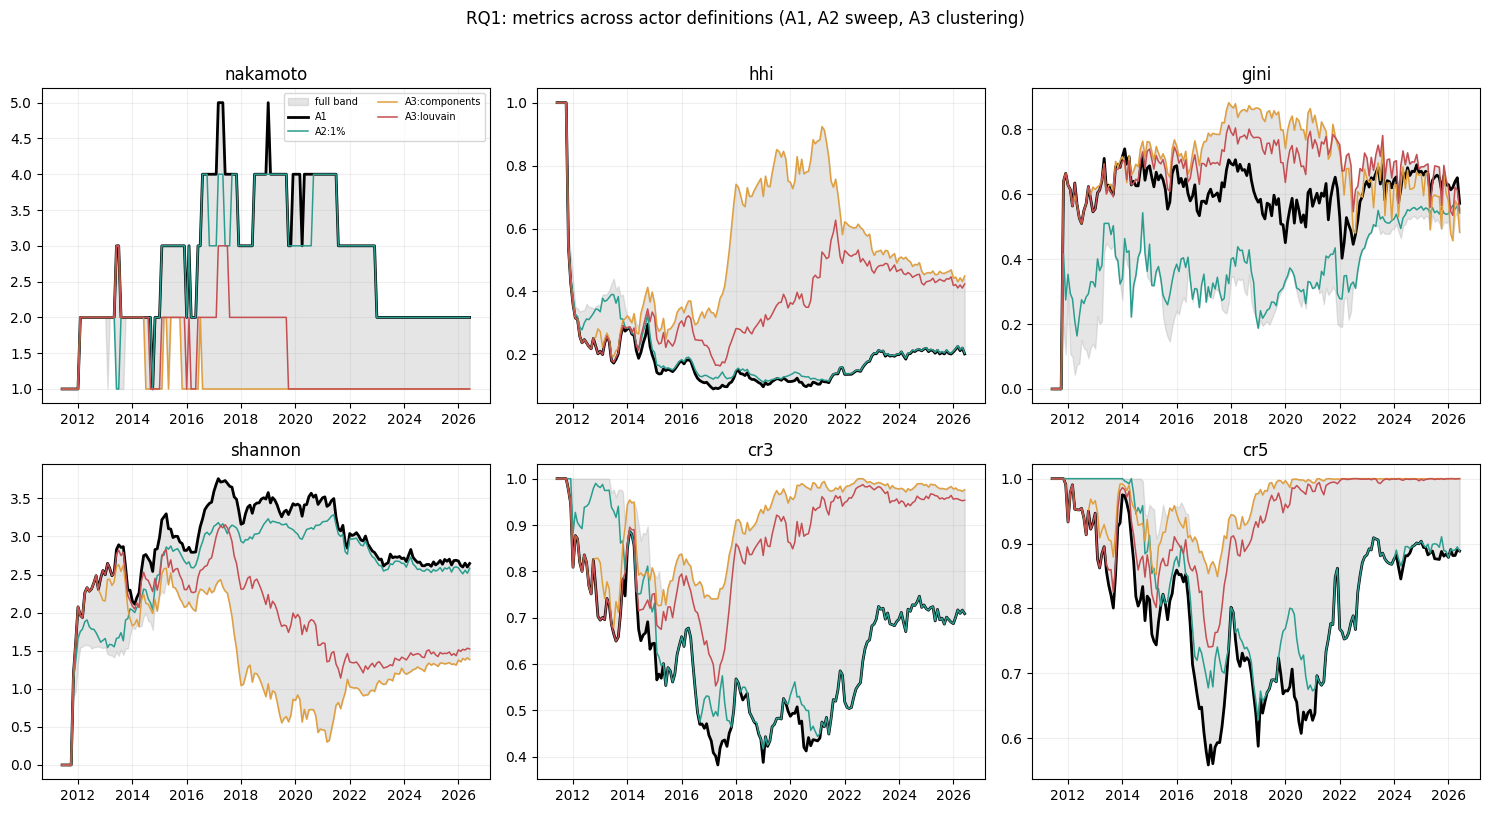

In [7]:
defs = list(series.keys())
colors = {"A1": "black", "A2:1%": "#2a9d8f", "A3:components": "#e09f3e", "A3:louvain": "#c44e52"}
show = ["A1", "A2:1%", "A3:components", "A3:louvain"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.ravel(), METRICS):
    common = None
    for d in defs:
        common = series[d].index if common is None else common.intersection(series[d].index)
    stack = np.vstack([series[d].loc[common, m].values for d in defs])
    ax.fill_between(common, stack.min(0), stack.max(0), color="gray", alpha=0.2, label="full band")
    for d in show:
        ax.plot(series[d].index, series[d][m].values, color=colors.get(d, "gray"),
                lw=2 if d == "A1" else 1.1, label=d)
    ax.set_title(m); ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle("RQ1: metrics across actor definitions (A1, A2 sweep, A3 clustering)", y=1.01)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/actor_definition_full_band.png", dpi=120, bbox_inches="tight")
plt.show()

## Quantify: full RQ1 band, and clustering vs thresholding

In [8]:
cut = pd.Timestamp("2018-01-01")
common = None
for d in defs:
    idx = series[d].index[series[d].index >= cut]
    common = idx if common is None else common.intersection(idx)

print(f"actor-definition sensitivity, mean over {len(common)} months (2018+):")
print(f"{'metric':9} {'A1 mean':>9} {'FULL band':>10} {'A2-only band':>13} {'A3 shift':>10}")
for m in METRICS:
    stack = np.vstack([series[d].loc[common, m].values for d in defs])
    full = (stack.max(0) - stack.min(0)).mean()
    a2 = np.vstack([series[d].loc[common, m].values for d in defs if d.startswith(("A1", "A2"))])
    a2band = (a2.max(0) - a2.min(0)).mean()
    a3 = np.abs(series["A3:louvain"].loc[common, m].values - series["A1"].loc[common, m].values).mean()
    print(f"{m:9} {series['A1'].loc[common, m].mean():9.3f} {full:10.3f} {a2band:13.3f} {a3:10.3f}")

actor-definition sensitivity, mean over 102 months (2018+):
metric      A1 mean  FULL band  A2-only band   A3 shift
nakamoto      2.931      1.931         0.186      1.725
hhi           0.159      0.474         0.015      0.266
gini          0.603      0.369         0.222      0.111
shannon       3.035      2.022         0.284      1.410
cr3           0.584      0.386         0.023      0.345
cr5           0.785      0.207         0.053      0.194
